# AdiVaani NMT — Data Exploration & Preprocessing
**MISN Lab, IIT Delhi**

This notebook covers:
1. Dataset loading and inspection
2. Statistical analysis
3. Cleaning and filtering
4. Train/Val split
5. SentencePiece tokenizer training

In [1]:
# Install dependencies
!pip install sentencepiece sacrebleu -q
print('✅ Dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.9 MB/s eta 0:00:00
✅ Dependencies installed


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import sentencepiece as spm
from collections import Counter

# Set seed for reproducibility
random.seed(42)
np.random.seed(42)

# ---- UPDATE THESE PATHS to match your Kaggle dataset path ----
TRAIN_HI = "/kaggle/input/datasets/erridhi/adivaani-hindi-marathi/train.hi"
TRAIN_MR = "/kaggle/input/datasets/erridhi/adivaani-hindi-marathi/train.mr"
TEST_HI  = "/kaggle/input/datasets/erridhi/adivaani-hindi-marathi/test.hi"
TEST_MR  = "/kaggle/input/datasets/erridhi/adivaani-hindi-marathi/test.mr"

OUTPUT_DIR = "/kaggle/working/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verify input files exist
for path in [TRAIN_HI, TRAIN_MR, TEST_HI, TEST_MR]:
    status = '✅' if os.path.exists(path) else '❌ NOT FOUND'
    print(f"{status} {path}")

✅ /kaggle/input/datasets/erridhi/adivaani-hindi-marathi/train.hi
✅ /kaggle/input/datasets/erridhi/adivaani-hindi-marathi/train.mr
✅ /kaggle/input/datasets/erridhi/adivaani-hindi-marathi/test.hi
✅ /kaggle/input/datasets/erridhi/adivaani-hindi-marathi/test.mr


## 1. Load Data

In [3]:
def load_file(path):
    with open(path, 'r', encoding='utf-8') as f:
        lines = [line.strip() for line in f.readlines()]
    return lines

train_hi = load_file(TRAIN_HI)
train_mr = load_file(TRAIN_MR)
test_hi  = load_file(TEST_HI)
test_mr  = load_file(TEST_MR)

print(f"✅ Train pairs : {len(train_hi):,}")
print(f"✅ Test pairs  : {len(test_hi):,}")
print()
print("Sample pair:")
print(f"  HI: {train_hi[0]}")
print(f"  MR: {train_mr[0]}")

✅ Train pairs : 241,847
✅ Test pairs  : 10,390

Sample pair:
  HI: इस  प्रयोग  को  नित्य  करने  से  दाँत  नहीं  सड़ते  ।
  MR: हा  प्रयोग  रोज  केल्याने  दात  खराब  होत  नाही  .


## 2. Statistical Analysis

In [4]:
def get_lengths(sentences):
    return [len(s.split()) for s in sentences]

hi_lengths = get_lengths(train_hi)
mr_lengths = get_lengths(train_mr)

print("=== Hindi Train ===")
print(f"  Avg length : {np.mean(hi_lengths):.1f} tokens")
print(f"  Max length : {max(hi_lengths)}")
print(f"  Min length : {min(hi_lengths)}")
print(f"  Std        : {np.std(hi_lengths):.1f}")
print()
print("=== Marathi Train ===")
print(f"  Avg length : {np.mean(mr_lengths):.1f} tokens")
print(f"  Max length : {max(mr_lengths)}")
print(f"  Min length : {min(mr_lengths)}")
print(f"  Std        : {np.std(mr_lengths):.1f}")

=== Hindi Train ===
  Avg length : 24.1 tokens
  Max length : 494
  Min length : 1
  Std        : 14.2

=== Marathi Train ===
  Avg length : 19.4 tokens
  Max length : 376
  Min length : 1
  Std        : 12.1


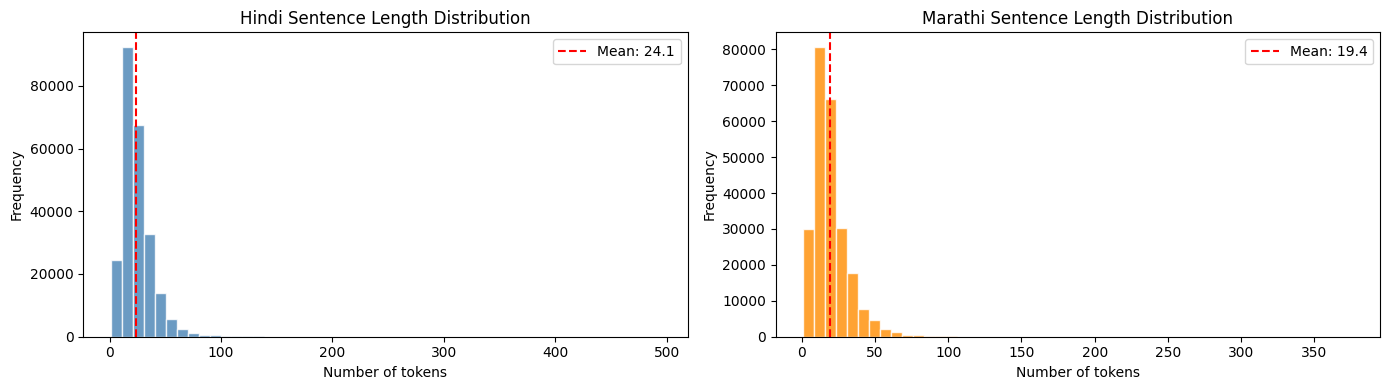

✅ Saved: length_distribution.png


In [5]:
# Plot length distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(hi_lengths, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Hindi Sentence Length Distribution')
axes[0].set_xlabel('Number of tokens')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.mean(hi_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(hi_lengths):.1f}')
axes[0].legend()

axes[1].hist(mr_lengths, bins=50, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_title('Marathi Sentence Length Distribution')
axes[1].set_xlabel('Number of tokens')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.mean(mr_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(mr_lengths):.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'length_distribution.png'), dpi=150)
plt.show()
print("✅ Saved: length_distribution.png")

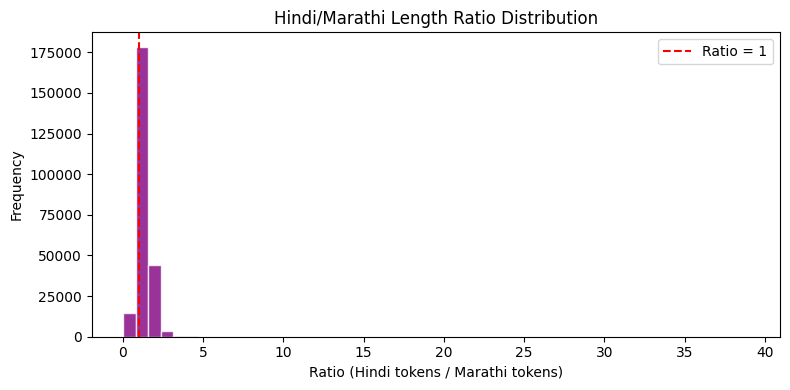

✅ Saved: length_ratio.png


In [6]:
# Length ratio distribution
ratios = [hi_lengths[i] / (mr_lengths[i] + 1e-6) for i in range(len(train_hi))]

plt.figure(figsize=(8, 4))
plt.hist(ratios, bins=50, color='purple', edgecolor='white', alpha=0.8)
plt.title('Hindi/Marathi Length Ratio Distribution')
plt.xlabel('Ratio (Hindi tokens / Marathi tokens)')
plt.ylabel('Frequency')
plt.axvline(1.0, color='red', linestyle='--', label='Ratio = 1')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'length_ratio.png'), dpi=150)
plt.show()
print("✅ Saved: length_ratio.png")

## 3. Data Cleaning & Filtering

In [7]:
def clean_sentence(s):
    # Normalize whitespace (data has extra spaces)
    return ' '.join(s.split())

def filter_pairs(src_lines, tgt_lines,
                 min_len=2, max_len=150, max_ratio=3.0):
    """
    Filter sentence pairs based on:
    - Minimum length
    - Maximum length
    - Maximum length ratio between src and tgt
    - Duplicates
    """
    filtered_src, filtered_tgt = [], []
    removed = {"empty": 0, "too_long": 0, "ratio": 0, "duplicate": 0}
    seen = set()

    for s, t in zip(src_lines, tgt_lines):
        s = clean_sentence(s)
        t = clean_sentence(t)

        s_len = len(s.split())
        t_len = len(t.split())

        # Empty / too short check
        if s_len < min_len or t_len < min_len:
            removed["empty"] += 1
            continue

        # Max length check
        if s_len > max_len or t_len > max_len:
            removed["too_long"] += 1
            continue

        # Length ratio check
        ratio = max(s_len, t_len) / (min(s_len, t_len) + 1e-6)
        if ratio > max_ratio:
            removed["ratio"] += 1
            continue

        # Duplicate check
        pair_key = (s, t)
        if pair_key in seen:
            removed["duplicate"] += 1
            continue
        seen.add(pair_key)

        filtered_src.append(s)
        filtered_tgt.append(t)

    return filtered_src, filtered_tgt, removed


clean_hi, clean_mr, removed = filter_pairs(train_hi, train_mr)

print(f"Original pairs  : {len(train_hi):,}")
print(f"After filtering : {len(clean_hi):,}")
print(f"Removed total   : {len(train_hi) - len(clean_hi):,}")
print(f"  - Too short   : {removed['empty']:,}")
print(f"  - Too long    : {removed['too_long']:,}")
print(f"  - Bad ratio   : {removed['ratio']:,}")
print(f"  - Duplicates  : {removed['duplicate']:,}")

Original pairs  : 241,847
After filtering : 235,888
Removed total   : 5,959
  - Too short   : 134
  - Too long    : 85
  - Bad ratio   : 1,068
  - Duplicates  : 4,672


## 4. Train / Validation Split

In [8]:
# Shuffle and split: 95% train, 5% val
pairs = list(zip(clean_hi, clean_mr))
random.shuffle(pairs)

val_size    = int(0.05 * len(pairs))
val_pairs   = pairs[:val_size]
train_pairs = pairs[val_size:]

print(f"✅ Train pairs : {len(train_pairs):,}")
print(f"✅ Val pairs   : {len(val_pairs):,}")
print(f"✅ Test pairs  : {len(test_hi):,}  (original test set, unchanged)")

# Unzip
final_train_hi, final_train_mr = zip(*train_pairs)
final_val_hi,   final_val_mr   = zip(*val_pairs)

✅ Train pairs : 224,094
✅ Val pairs   : 11,794
✅ Test pairs  : 10,390  (original test set, unchanged)


In [9]:
def save_lines(lines, path):
    with open(path, 'w', encoding='utf-8') as f:
        for line in lines:
            f.write(line + '\n')
    print(f"✅ Saved {len(lines):,} lines → {path}")

save_lines(final_train_hi, os.path.join(OUTPUT_DIR, 'train.hi'))
save_lines(final_train_mr, os.path.join(OUTPUT_DIR, 'train.mr'))
save_lines(final_val_hi,   os.path.join(OUTPUT_DIR, 'val.hi'))
save_lines(final_val_mr,   os.path.join(OUTPUT_DIR, 'val.mr'))

# Clean and save test set too
clean_test_hi = [clean_sentence(s) for s in test_hi]
clean_test_mr = [clean_sentence(s) for s in test_mr]
save_lines(clean_test_hi, os.path.join(OUTPUT_DIR, 'test.hi'))
save_lines(clean_test_mr, os.path.join(OUTPUT_DIR, 'test.mr'))

✅ Saved 224,094 lines → /kaggle/working/train.hi
✅ Saved 224,094 lines → /kaggle/working/train.mr
✅ Saved 11,794 lines → /kaggle/working/val.hi
✅ Saved 11,794 lines → /kaggle/working/val.mr
✅ Saved 10,390 lines → /kaggle/working/test.hi
✅ Saved 10,390 lines → /kaggle/working/test.mr


## 5. Train SentencePiece Tokenizer (Shared BPE)

In [10]:
# Combine Hindi + Marathi train text into one file for shared tokenizer
combined_path = os.path.join(OUTPUT_DIR, 'combined_train.txt')

with open(combined_path, 'w', encoding='utf-8') as f:
    for line in final_train_hi:
        f.write(line + '\n')
    for line in final_train_mr:
        f.write(line + '\n')

# Verify file was created
if os.path.exists(combined_path):
    size_mb = os.path.getsize(combined_path) / (1024 * 1024)
    print(f"✅ Combined file created: {len(final_train_hi) + len(final_train_mr):,} lines, {size_mb:.1f} MB")
else:
    print("❌ Failed to create combined file")

✅ Combined file created: 448,188 lines, 140.6 MB


In [11]:
# Train SentencePiece BPE tokenizer
# Shared vocab makes sense — Hindi & Marathi share Devanagari script and Sanskrit roots

SPM_PREFIX = os.path.join(OUTPUT_DIR, 'spm_hi_mr')
VOCAB_SIZE  = 8000

print("Training SentencePiece tokenizer... (this takes 1-2 minutes)")

try:
    spm.SentencePieceTrainer.train(
        input=combined_path,
        model_prefix=SPM_PREFIX,
        vocab_size=VOCAB_SIZE,
        model_type='bpe',
        character_coverage=0.9999,
        pad_id=0,
        unk_id=1,
        bos_id=2,
        eos_id=3,
        pad_piece='<pad>',
        unk_piece='<unk>',
        bos_piece='<s>',
        eos_piece='</s>',
    )
    print("✅ Tokenizer training complete!")
except Exception as e:
    print(f"❌ Training failed: {e}")
    raise

Training SentencePiece tokenizer... (this takes 1-2 minutes)
✅ Tokenizer training complete!


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /kaggle/working/combined_train.txt
  input_format: 
  model_prefix: /kaggle/working/spm_hi_mr
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9999
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enab

In [12]:
# Verify tokenizer files were created
model_path = SPM_PREFIX + '.model'
vocab_path  = SPM_PREFIX + '.vocab'

if os.path.exists(model_path):
    print(f"✅ Model file : {model_path}  ({os.path.getsize(model_path)/1024:.1f} KB)")
else:
    print("❌ Model file not found")

if os.path.exists(vocab_path):
    print(f"✅ Vocab file : {vocab_path}  ({os.path.getsize(vocab_path)/1024:.1f} KB)")
else:
    print("❌ Vocab file not found")

✅ Model file : /kaggle/working/spm_hi_mr.model  (421.8 KB)
✅ Vocab file : /kaggle/working/spm_hi_mr.vocab  (170.6 KB)


In [13]:
# Load and test the tokenizer
sp = spm.SentencePieceProcessor()
sp.load(SPM_PREFIX + '.model')

sample_hi = final_train_hi[0]
sample_mr = final_train_mr[0]

print("=== Tokenization Test ===")
print(f"Hindi original : {sample_hi}")
print(f"Hindi tokens   : {sp.encode(sample_hi, out_type=str)}")
print(f"Hindi IDs      : {sp.encode(sample_hi)}")
print()
print(f"Marathi original : {sample_mr}")
print(f"Marathi tokens   : {sp.encode(sample_mr, out_type=str)}")
print(f"Marathi IDs      : {sp.encode(sample_mr)}")
print()
print(f"Vocab size: {sp.get_piece_size()}")
print()
# Decode back to verify roundtrip
print("Decoded back (roundtrip check):")
print(f"  HI: {sp.decode(sp.encode(sample_hi))}")
print(f"  MR: {sp.decode(sp.encode(sample_mr))}")

=== Tokenization Test ===
Hindi original : समान अवधि के लिए पिछले वर्ष की तुलना में समान भंडारण वाले राज्य उत्तर प्रदेश और तेलंगाना हैं।
Hindi tokens   : ['▁समान', '▁अवधि', '▁के', '▁लिए', '▁पिछले', '▁वर्ष', '▁की', '▁तुलना', '▁में', '▁समान', '▁भंडारण', '▁वाले', '▁राज्य', '▁उत्तर', '▁प्रदेश', '▁और', '▁तेलंग', 'ाना', '▁हैं', '।']
Hindi IDs      : [2047, 2654, 16, 94, 1586, 337, 56, 2815, 45, 2047, 7079, 837, 385, 877, 764, 40, 5754, 327, 117, 7886]

Marathi original : उत्तर प्रदेश आणि तेलंगणामधे गेल्यावर्षी एवढाच पाणीसाठा उपलब्ध आहे.
Marathi tokens   : ['▁उत्तर', '▁प्रदेश', '▁आणि', '▁तेलंग', 'णा', 'मधे', '▁गेल्या', 'वर्षी', '▁एव', 'ढा', 'च', '▁पाणी', 'सा', 'ठा', '▁उपलब्ध', '▁आहे', '.']
Marathi IDs      : [877, 764, 74, 5754, 121, 5962, 1558, 3128, 1572, 1083, 7867, 1864, 70, 594, 835, 65, 7881]

Vocab size: 8000

Decoded back (roundtrip check):
  HI: समान अवधि के लिए पिछले वर्ष की तुलना में समान भंडारण वाले राज्य उत्तर प्रदेश और तेलंगाना हैं।
  MR: उत्तर प्रदेश आणि तेलंगणामधे गेल्यावर्षी 

In [14]:
# BPE token length stats
sample_size = 10000
bpe_hi_lens = [len(sp.encode(s)) for s in list(final_train_hi)[:sample_size]]
bpe_mr_lens = [len(sp.encode(s)) for s in list(final_train_mr)[:sample_size]]

print(f"After BPE tokenization (sample of {sample_size:,}):")
print(f"  Hindi   avg : {np.mean(bpe_hi_lens):.1f} subword tokens")
print(f"  Marathi avg : {np.mean(bpe_mr_lens):.1f} subword tokens")
print(f"  Hindi   max : {max(bpe_hi_lens)}")
print(f"  Marathi max : {max(bpe_mr_lens)}")
print()

# Coverage within max_seq_len
for max_len in [64, 128, 256]:
    pct_hi = sum(1 for l in bpe_hi_lens if l <= max_len) / len(bpe_hi_lens) * 100
    pct_mr = sum(1 for l in bpe_mr_lens if l <= max_len) / len(bpe_mr_lens) * 100
    print(f"  Within {max_len} tokens → Hindi: {pct_hi:.1f}%  Marathi: {pct_mr:.1f}%")

print()
print("→ Recommended max_seq_len for model: 128")

After BPE tokenization (sample of 10,000):
  Hindi   avg : 33.2 subword tokens
  Marathi avg : 31.6 subword tokens
  Hindi   max : 293
  Marathi max : 272

  Within 64 tokens → Hindi: 93.5%  Marathi: 94.2%
  Within 128 tokens → Hindi: 99.5%  Marathi: 99.6%
  Within 256 tokens → Hindi: 100.0%  Marathi: 100.0%

→ Recommended max_seq_len for model: 128


## 6. X Factor — Shared Vocabulary Analysis
*(Unique analysis showing linguistic overlap between Hindi and Marathi)*

In [15]:
# Load vocab
with open(vocab_path, 'r', encoding='utf-8') as f:
    vocab_lines = f.readlines()

all_tokens = [line.split('\t')[0] for line in vocab_lines]

# Tokenize a sample of Hindi and Marathi sentences separately
sample_size = 5000

hi_token_set = set()
for s in list(final_train_hi)[:sample_size]:
    hi_token_set.update(sp.encode(s, out_type=str))

mr_token_set = set()
for s in list(final_train_mr)[:sample_size]:
    mr_token_set.update(sp.encode(s, out_type=str))

shared  = hi_token_set & mr_token_set
hi_only = hi_token_set - mr_token_set
mr_only = mr_token_set - hi_token_set

print("=== Shared Vocabulary Analysis ===")
print(f"Unique tokens in Hindi sample   : {len(hi_token_set):,}")
print(f"Unique tokens in Marathi sample : {len(mr_token_set):,}")
print(f"Shared tokens (both languages)  : {len(shared):,}")
print(f"Hindi only                      : {len(hi_only):,}")
print(f"Marathi only                    : {len(mr_only):,}")
print()
print(f"% of Hindi tokens shared with Marathi  : {len(shared)/len(hi_token_set)*100:.1f}%")
print(f"% of Marathi tokens shared with Hindi  : {len(shared)/len(mr_token_set)*100:.1f}%")
print()
print("This high overlap JUSTIFIES our shared BPE vocabulary choice.")
print("Both languages share Devanagari script and Sanskrit-derived subwords.")

=== Shared Vocabulary Analysis ===
Unique tokens in Hindi sample   : 5,425
Unique tokens in Marathi sample : 6,472
Shared tokens (both languages)  : 4,119
Hindi only                      : 1,306
Marathi only                    : 2,353

% of Hindi tokens shared with Marathi  : 75.9%
% of Marathi tokens shared with Hindi  : 63.6%

This high overlap JUSTIFIES our shared BPE vocabulary choice.
Both languages share Devanagari script and Sanskrit-derived subwords.


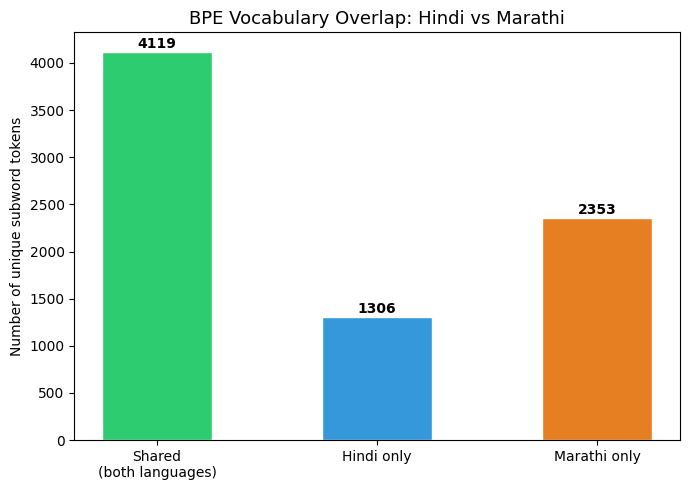

✅ Saved: vocab_overlap.png


In [16]:
# Visualize shared vocab
labels  = ['Shared\n(both languages)', 'Hindi only', 'Marathi only']
sizes   = [len(shared), len(hi_only), len(mr_only)]
colors  = ['#2ecc71', '#3498db', '#e67e22']

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, sizes, color=colors, edgecolor='white', width=0.5)
plt.title('BPE Vocabulary Overlap: Hindi vs Marathi', fontsize=13)
plt.ylabel('Number of unique subword tokens')
for bar, size in zip(bars, sizes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(size), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vocab_overlap.png'), dpi=150)
plt.show()
print("✅ Saved: vocab_overlap.png")

## 7. Final Summary

In [17]:
print("="*55)
print("DATASET SUMMARY")
print("="*55)
print(f"Train pairs        : {len(final_train_hi):,}")
print(f"Val pairs          : {len(final_val_hi):,}")
print(f"Test pairs         : {len(clean_test_hi):,}")
print(f"Shared vocab size  : {sp.get_piece_size():,}")
print(f"Tokenizer type     : BPE (SentencePiece)")
print(f"Recommended max_len: 128 tokens")
print()
print("Output files saved to /kaggle/working/:")
files = ['train.hi','train.mr','val.hi','val.mr',
         'test.hi','test.mr','spm_hi_mr.model','spm_hi_mr.vocab',
         'length_distribution.png','length_ratio.png','vocab_overlap.png']
for fname in files:
    fpath = os.path.join(OUTPUT_DIR, fname)
    status = '✅' if os.path.exists(fpath) else '❌ MISSING'
    print(f"  {status} {fname}")
print()
print("✅ Notebook complete! Ready for LSTM training.")

DATASET SUMMARY
Train pairs        : 224,094
Val pairs          : 11,794
Test pairs         : 10,390
Shared vocab size  : 8,000
Tokenizer type     : BPE (SentencePiece)
Recommended max_len: 128 tokens

Output files saved to /kaggle/working/:
  ✅ train.hi
  ✅ train.mr
  ✅ val.hi
  ✅ val.mr
  ✅ test.hi
  ✅ test.mr
  ✅ spm_hi_mr.model
  ✅ spm_hi_mr.vocab
  ✅ length_distribution.png
  ✅ length_ratio.png
  ✅ vocab_overlap.png

✅ Notebook complete! Ready for LSTM training.
